In [36]:
print("="*80)
print("CHAPTER 6: CONVERGENCE AND ADAPTIVE ITERATION ANALYSIS")
print("="*80)
print()
print("Objectives:")
print("1. Implement TRUE Efficient Global Optimisation (EGO) with Expected Improvement")
print("2. Track convergence metrics for TR and PD")
print("3. Analyze surrogate model improvement with adaptive sampling")
print("="*80)

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from smt.surrogate_models import KRG
from smt.applications.ego import EGO
from smt.sampling_methods import LHS

print("\nLibraries imported successfully!")
print("- NumPy, Matplotlib, Pandas")
print("- SMT Kriging (KRG) surrogate model")
print("- SMT EGO (Efficient Global Optimisation)")
print("- SMT LHS (Latin Hypercube Sampling)")

CHAPTER 6: CONVERGENCE AND ADAPTIVE ITERATION ANALYSIS

Objectives:
1. Implement TRUE Efficient Global Optimisation (EGO) with Expected Improvement
2. Track convergence metrics for TR and PD
3. Analyze surrogate model improvement with adaptive sampling

Libraries imported successfully!
- NumPy, Matplotlib, Pandas
- SMT Kriging (KRG) surrogate model
- SMT EGO (Efficient Global Optimisation)
- SMT LHS (Latin Hypercube Sampling)


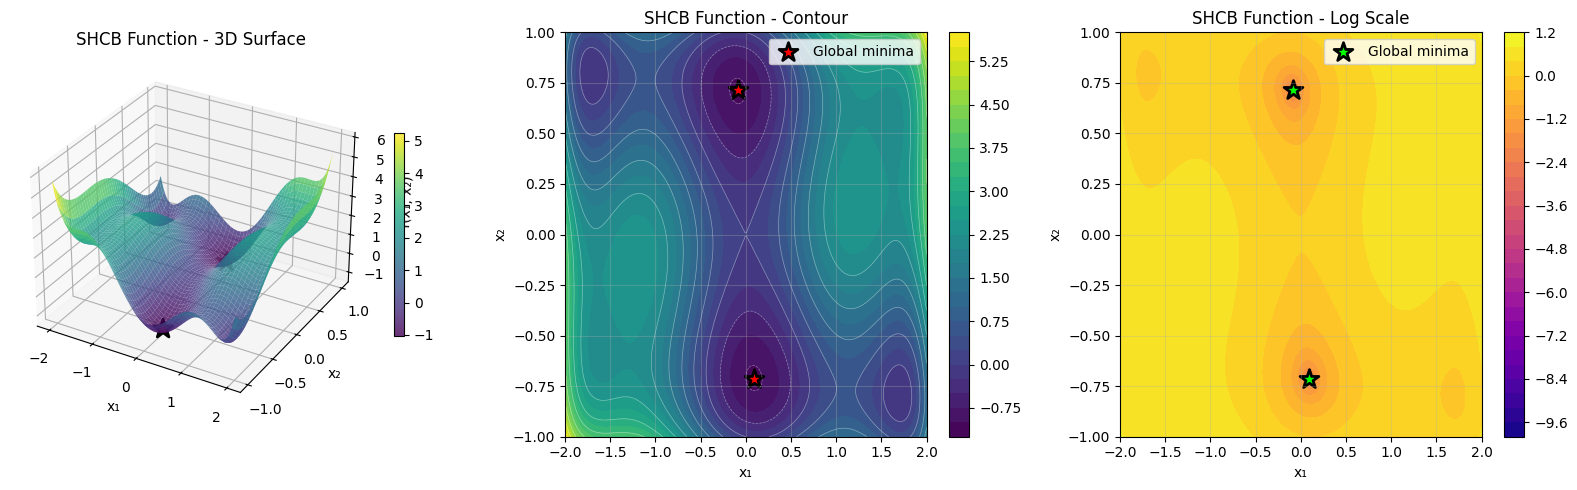


SHCB Function Properties:
  Domain: x₁ ∈ [-2, 2], x₂ ∈ [-1, 1]
  Global minimum: f = -1.0316 at (±0.0898, ∓0.7127)
  Number of local minima: 6
  Challenge: Multiple local minima test adaptive sampling


In [25]:
# Cell 2: Define SHCB function
def six_hump_camelback(X):
    """
    Six-Hump Camelback benchmark function.
    
    Domain: x1 ∈ [-2, 2], x2 ∈ [-1, 1]
    Global minima: f = -1.0316 at (±0.0898, ∓0.7127)
    
    Parameters:
        X: array of shape (n_samples, 2)
    
    Returns:
        y: array of shape (n_samples, 1)
    """
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    
    term1 = (4 - 2.1 * x1**2 + (x1**4) / 3) * x1**2
    term2 = x1 * x2
    term3 = (-4 + 4 * x2**2) * x2**2
    
    y = term1 + term2 + term3
    
    return y.reshape(-1, 1)

# Define design space
xlimits = np.array([[-2.0, 2.0], [-1.0, 1.0]])
design_space = DesignSpace(xlimits, seed=42)

# Visualize SHCB function
x1_plot = np.linspace(-2, 2, 200)
x2_plot = np.linspace(-1, 1, 200)
X1_grid, X2_grid = np.meshgrid(x1_plot, x2_plot)
X_grid = np.column_stack((X1_grid.ravel(), X2_grid.ravel()))
Y_grid = six_hump_camelback(X_grid).reshape(X1_grid.shape)

fig = plt.figure(figsize=(16, 5))

# 3D surface
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X1_grid, X2_grid, Y_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter([0.0898, -0.0898], [-0.7127, 0.7127], [-1.0316, -1.0316], 
            c='red', s=200, marker='*', edgecolors='black', linewidths=2)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('f(x₁, x₂)')
ax1.set_title('SHCB Function - 3D Surface')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contourf(X1_grid, X2_grid, Y_grid, levels=30, cmap='viridis')
ax2.contour(X1_grid, X2_grid, Y_grid, levels=15, colors='white', alpha=0.4, linewidths=0.5)
ax2.scatter([0.0898, -0.0898], [-0.7127, 0.7127], c='red', s=200, marker='*', 
            edgecolors='black', linewidths=2, label='Global minima')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('SHCB Function - Contour')
ax2.legend()
ax2.grid(True, alpha=0.3)
fig.colorbar(contour, ax=ax2)

# Log-scale contour to show structure
ax3 = fig.add_subplot(133)
Y_log = np.log10(Y_grid - Y_grid.min() + 1e-10)
contour2 = ax3.contourf(X1_grid, X2_grid, Y_log, levels=30, cmap='plasma')
ax3.scatter([0.0898, -0.0898], [-0.7127, 0.7127], c='lime', s=200, marker='*',
            edgecolors='black', linewidths=2, label='Global minima')
ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title('SHCB Function - Log Scale')
ax3.legend()
ax3.grid(True, alpha=0.3)
fig.colorbar(contour2, ax=ax3)

plt.tight_layout()
plt.show()

print(f"\nSHCB Function Properties:")
print(f"  Domain: x₁ ∈ [-2, 2], x₂ ∈ [-1, 1]")
print(f"  Global minimum: f = -1.0316 at (±0.0898, ∓0.7127)")
print(f"  Number of local minima: 6")
print(f"  Challenge: Multiple local minima test adaptive sampling")

In [8]:
# Cell 2: Define SHCB function
def six_hump_camelback(X):
    """
    Six-Hump Camelback benchmark function.
    
    Domain: x1 ∈ [-2, 2], x2 ∈ [-1, 1]
    Global minima: f = -1.0316 at (±0.0898, ∓0.7127)
    
    Parameters:
        X: array of shape (n_samples, 2)
    
    Returns:
        y: array of shape (n_samples, 1)
    """
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    
    term1 = (4 - 2.1 * x1**2 + (x1**4) / 3) * x1**2
    term2 = x1 * x2
    term3 = (-4 + 4 * x2**2) * x2**2
    
    y = term1 + term2 + term3
    
    return y.reshape(-1, 1)

# Define design space
xlimits = np.array([[-2.0, 2.0], [-1.0, 1.0]])
design_space = DesignSpace(xlimits, seed=42)

# Visualize SHCB function
x1_plot = np.linspace(-2, 2, 200)
x2_plot = np.linspace(-1, 1, 200)
X1_grid, X2_grid = np.meshgrid(x1_plot, x2_plot)
X_grid = np.column_stack((X1_grid.ravel(), X2_grid.ravel()))
Y_grid = six_hump_camelback(X_grid).reshape(X1_grid.shape)

fig = plt.figure(figsize=(16, 5))

# 3D surface
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X1_grid, X2_grid, Y_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter([0.0898, -0.0898], [-0.7127, 0.7127], [-1.0316, -1.0316], 
            c='red', s=200, marker='*', edgecolors='black', linewidths=2)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('f(x₁, x₂)')
ax1.set_title('SHCB Function - 3D Surface')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contourf(X1_grid, X2_grid, Y_grid, levels=30, cmap='viridis')
ax2.contour(X1_grid, X2_grid, Y_grid, levels=15, colors='white', alpha=0.4, linewidths=0.5)
ax2.scatter([0.0898, -0.0898], [-0.7127, 0.7127], c='red', s=200, marker='*', 
            edgecolors='black', linewidths=2, label='Global minima')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('SHCB Function - Contour')
ax2.legend()
ax2.grid(True, alpha=0.3)
fig.colorbar(contour, ax=ax2)

# Log-scale contour to show structure
ax3 = fig.add_subplot(133)
Y_log = np.log10(Y_grid - Y_grid.min() + 1e-10)
contour2 = ax3.contourf(X1_grid, X2_grid, Y_log, levels=30, cmap='plasma')
ax3.scatter([0.0898, -0.0898], [-0.7127, 0.7127], c='lime', s=200, marker='*',
            edgecolors='black', linewidths=2, label='Global minima')
ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title('SHCB Function - Log Scale')
ax3.legend()
ax3.grid(True, alpha=0.3)
fig.colorbar(contour2, ax=ax3)

plt.tight_layout()
plt.show()

print(f"\nSHCB Function Properties:")
print(f"  Domain: x₁ ∈ [-2, 2], x₂ ∈ [-1, 1]")
print(f"  Global minimum: f = -1.0316 at (±0.0898, ∓0.7127)")
print(f"  Number of local minima: 6")
print(f"  Challenge: Multiple local minima test adaptive sampling")

Initial DOE: 10 points
TR range in DOE: [0.1626, 0.2176]
PD range in DOE: [13858.3, 31986.3]


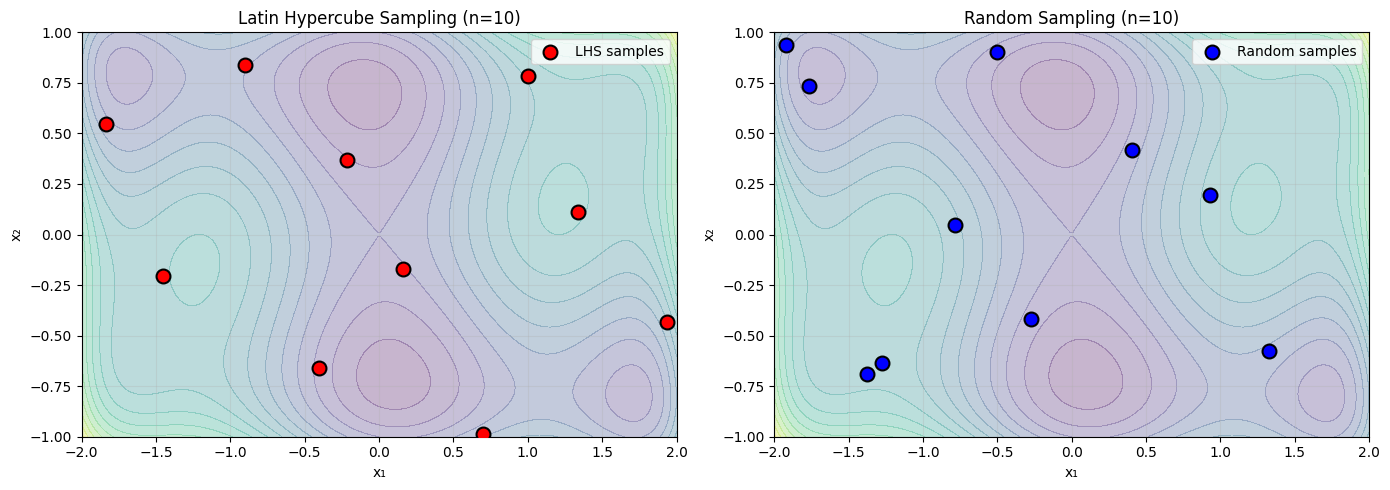


Initial DOE comparison:
  LHS ensures space-filling coverage across the domain
  Random sampling can leave gaps and create clusters


In [27]:
# Cell 3: Define sampling strategies
def create_lhs_sample(n_samples, xlimits, seed=42):
    """Create Latin Hypercube Sample"""
    sampling = LHS(xlimits=xlimits, criterion='ese')
    sampling.random_state = seed
    return sampling(n_samples)

def create_random_sample(n_samples, xlimits, seed=42):
    """Create random sample"""
    np.random.seed(seed)
    X = np.random.uniform(
        low=xlimits[:, 0],
        high=xlimits[:, 1],
        size=(n_samples, xlimits.shape[0])
    )
    return X

# Compare initial DOE strategies
n_initial = 10
seed = 42

X_lhs = create_lhs_sample(n_initial, xlimits, seed)
X_random = create_random_sample(n_initial, xlimits, seed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LHS
ax1.contourf(X1_grid, X2_grid, Y_grid, levels=20, cmap='viridis', alpha=0.3)
ax1.scatter(X_lhs[:, 0], X_lhs[:, 1], c='red', s=100, edgecolors='black', 
            linewidths=1.5, label='LHS samples', zorder=5)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title(f'Latin Hypercube Sampling (n={n_initial})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Random
ax2.contourf(X1_grid, X2_grid, Y_grid, levels=20, cmap='viridis', alpha=0.3)
ax2.scatter(X_random[:, 0], X_random[:, 1], c='blue', s=100, edgecolors='black',
            linewidths=1.5, label='Random samples', zorder=5)
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title(f'Random Sampling (n={n_initial})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInitial DOE comparison:")
print(f"  LHS ensures space-filling coverage across the domain")
print(f"  Random sampling can leave gaps and create clusters")

In [28]:
# Cell 4: Setup EGO adaptive sampling
n_iter = 20  # Number of adaptive iterations
n_initial_doe = 10
criterion = 'EI'  # Expected Improvement

print(f"\nEGO Configuration:")
print(f"  Initial DOE: {n_initial_doe} points (LHS)")
print(f"  Adaptive iterations: {n_iter}")
print(f"  Infill criterion: {criterion} (Expected Improvement)")
print(f"  Surrogate model: Kriging (Gaussian Process)")

# Create initial DOE
X_doe = create_lhs_sample(n_initial_doe, xlimits, seed)
y_doe = six_hump_camelback(X_doe)

# Setup Kriging surrogate
sm = KRG(
    design_space=design_space,
    theta0=[1e-2],
    print_global=False,
    hyper_opt='Cobyla'
)

# Setup EGO
ego = EGO(
    n_iter=n_iter,
    criterion=criterion,
    xdoe=X_doe,
    ydoe=y_doe,
    surrogate=sm,
    n_start=30,
    seed=seed,
    verbose=False
)

print(f"\n{'='*60}")
print("Starting EGO adaptive sampling...")
print(f"{'='*60}")


EGO Configuration:
  Initial DOE: 10 points (LHS)
  Adaptive iterations: 20
  Infill criterion: EI (Expected Improvement)
  Surrogate model: Kriging (Gaussian Process)

Starting EGO adaptive sampling...


In [29]:
# Cell 5: Run EGO optimization
x_opt, y_opt, _, x_data, y_data = ego.optimize(fun=six_hump_camelback)

# Ensure proper shapes
x_opt = np.asarray(x_opt).reshape(-1)
y_opt = np.asarray(y_opt).reshape(-1)
x_data = np.asarray(x_data)
y_data = np.asarray(y_data).reshape(-1)

# Known global minimum
x_global = np.array([0.0898, -0.7127])
y_global = -1.0316

error_final = abs(y_opt[0] - y_global)
distance_to_global = np.linalg.norm(x_opt - x_global)

print(f"\n{'='*60}")
print("EGO OPTIMIZATION COMPLETE")
print(f"{'='*60}")
print(f"Found optimum:")
print(f"  x* = ({x_opt[0]:.4f}, {x_opt[1]:.4f})")
print(f"  f(x*) = {y_opt[0]:.6f}")
print(f"\nTrue global minimum:")
print(f"  x_true = ({x_global[0]:.4f}, {x_global[1]:.4f})")
print(f"  f(x_true) = {y_global:.6f}")
print(f"\nError metrics:")
print(f"  Absolute error: {error_final:.6f}")
print(f"  Relative error: {abs(error_final / y_global) * 100:.3f}%")
print(f"  Distance to global optimum: {distance_to_global:.4f}")
print(f"  Total function evaluations: {len(y_data)}")
print(f"{'='*60}")


EGO OPTIMIZATION COMPLETE
Found optimum:
  x* = (0.1068, -0.6956)
  f(x*) = -1.027880

True global minimum:
  x_true = (0.0898, -0.7127)
  f(x_true) = -1.031600

Error metrics:
  Absolute error: 0.003720
  Relative error: 0.361%
  Distance to global optimum: 0.0242
  Total function evaluations: 30


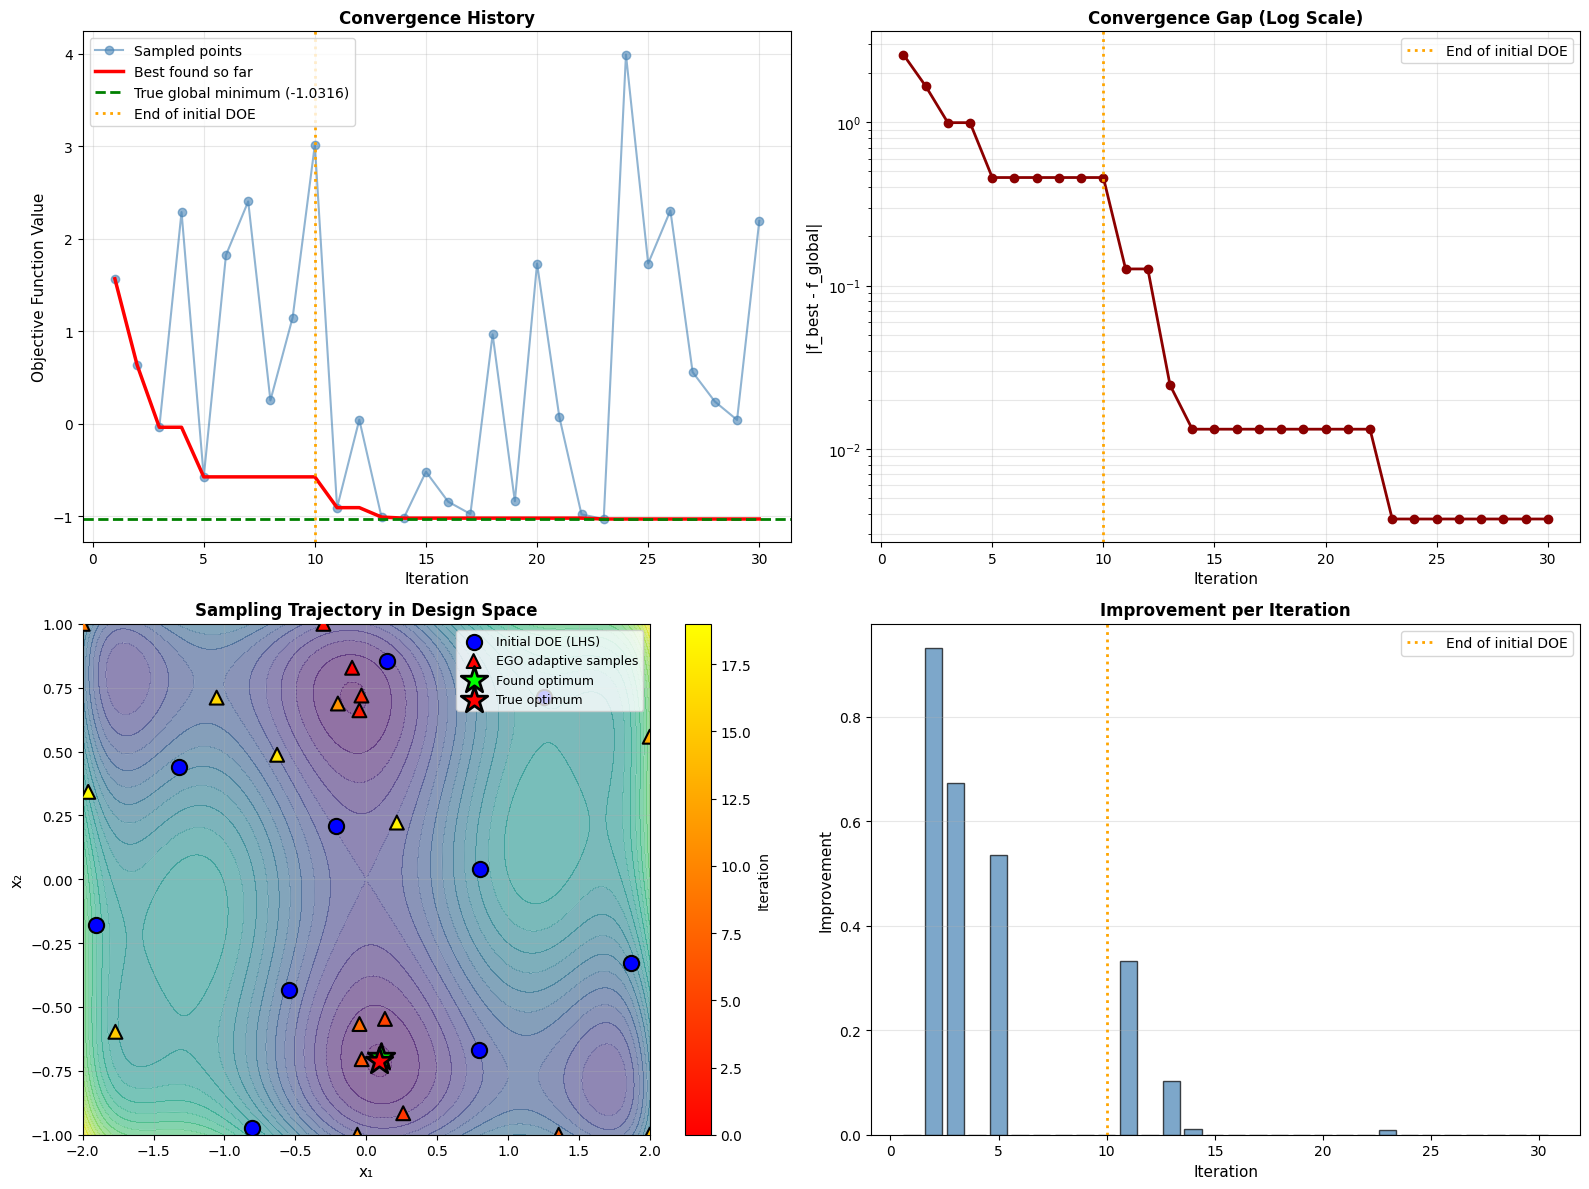

In [30]:
# Cell 6: Convergence analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Convergence plot
iterations = np.arange(1, len(y_data) + 1)
y_min_history = np.minimum.accumulate(y_data)

ax = axes[0, 0]
ax.plot(iterations, y_data, 'o-', alpha=0.6, label='Sampled points', color='steelblue')
ax.plot(iterations, y_min_history, 'r-', linewidth=2.5, label='Best found so far')
ax.axhline(y=y_global, color='green', linestyle='--', linewidth=2, 
           label=f'True global minimum ({y_global:.4f})')
ax.axvline(x=n_initial_doe, color='orange', linestyle=':', linewidth=2,
           label='End of initial DOE')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Objective Function Value', fontsize=11)
ax.set_title('Convergence History', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Log-scale convergence gap
ax = axes[0, 1]
gap = np.abs(y_min_history - y_global)
gap[gap < 1e-10] = 1e-10
ax.semilogy(iterations, gap, 'o-', linewidth=2, color='darkred')
ax.axvline(x=n_initial_doe, color='orange', linestyle=':', linewidth=2,
           label='End of initial DOE')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('|f_best - f_global|', fontsize=11)
ax.set_title('Convergence Gap (Log Scale)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# Sampling trajectory
ax = axes[1, 0]
contour = ax.contourf(X1_grid, X2_grid, Y_grid, levels=30, cmap='viridis', alpha=0.6)
ax.contour(X1_grid, X2_grid, Y_grid, levels=15, colors='white', alpha=0.3, linewidths=0.5)

# Initial DOE
ax.scatter(x_data[:n_initial_doe, 0], x_data[:n_initial_doe, 1],
           c='blue', s=120, marker='o', edgecolors='black', linewidths=1.5,
           label='Initial DOE (LHS)', zorder=5)

# Adaptive samples
if len(x_data) > n_initial_doe:
    scatter = ax.scatter(
        x_data[n_initial_doe:, 0], x_data[n_initial_doe:, 1],
        c=np.arange(len(x_data) - n_initial_doe),
        cmap='autumn', s=100, marker='^', edgecolors='black',
        linewidths=1.5, label='EGO adaptive samples', zorder=6
    )
    plt.colorbar(scatter, ax=ax, label='Iteration')

# Optimum
ax.scatter(x_opt[0], x_opt[1], c='lime', s=400, marker='*',
           edgecolors='black', linewidths=2, label='Found optimum', zorder=10)
ax.scatter(x_global[0], x_global[1], c='red', s=400, marker='*',
           edgecolors='black', linewidths=2, label='True optimum', zorder=10)

ax.set_xlabel('x₁', fontsize=11)
ax.set_ylabel('x₂', fontsize=11)
ax.set_title('Sampling Trajectory in Design Space', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Improvement per iteration
ax = axes[1, 1]
improvements = np.diff(y_min_history, prepend=y_min_history[0])
improvements[0] = 0
ax.bar(iterations, -improvements, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(x=n_initial_doe, color='orange', linestyle=':', linewidth=2,
           label='End of initial DOE')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Improvement', fontsize=11)
ax.set_title('Improvement per Iteration', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

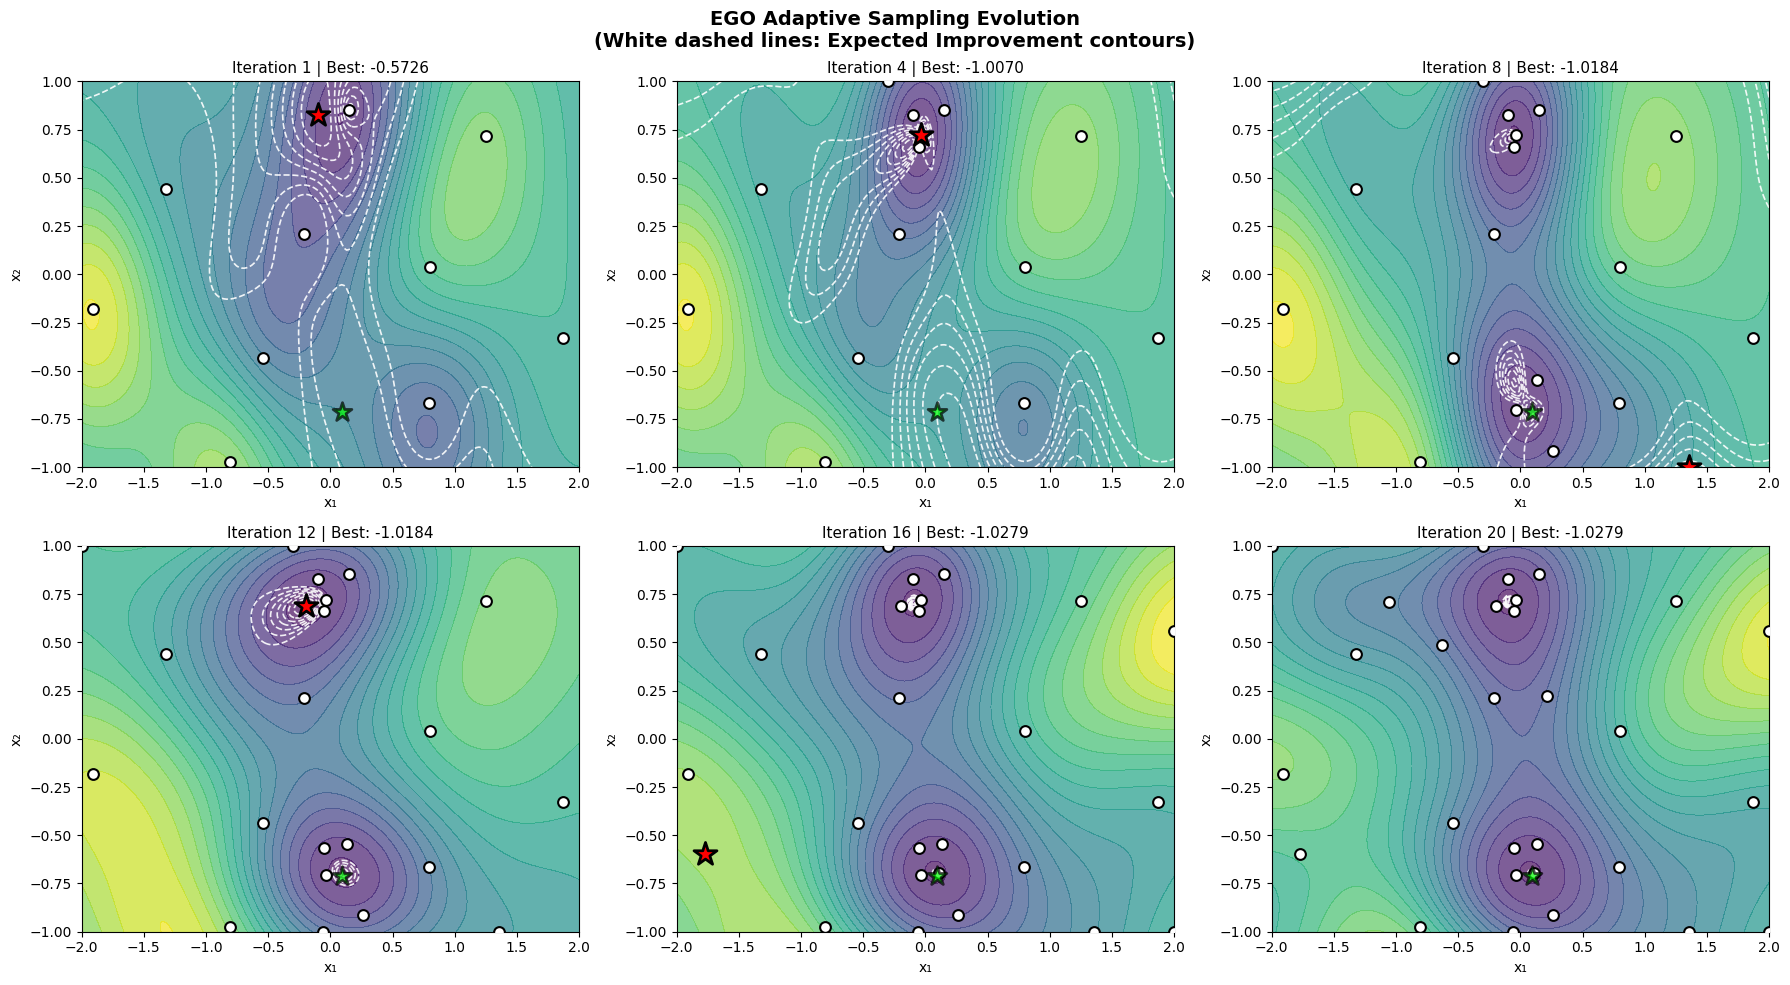

In [31]:
# Cell 7: Adaptive sampling evolution (snapshots)
n_snapshots = min(6, n_iter)
snapshot_iters = np.linspace(0, n_iter-1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, i in enumerate(snapshot_iters):
    k = n_initial_doe + i
    x_data_k = x_data[:k]
    y_data_k = y_data[:k].reshape(-1, 1)
    
    ego.gpr.set_training_values(x_data_k, y_data_k)
    ego.gpr.train()
    
    y_pred = ego.gpr.predict_values(X_grid).reshape(X1_grid.shape)
    ei_values = -ego.EI(X_grid).reshape(X1_grid.shape)
    
    ax = axes[idx]
    
    # Predicted surface
    contour = ax.contourf(X1_grid, X2_grid, y_pred, levels=20, cmap='viridis', alpha=0.7)
    
    # EI contours
    ax.contour(X1_grid, X2_grid, ei_values, levels=8, colors='white', 
               linewidths=1.2, alpha=0.9, linestyles='dashed')
    
    # Sampled points
    ax.scatter(x_data_k[:, 0], x_data_k[:, 1], c='white', s=60,
               edgecolors='black', linewidths=1.5, zorder=5)
    
    # Next sample point
    if i < n_iter - 1:
        ax.scatter(x_data[k, 0], x_data[k, 1], c='red', marker='*', s=300,
                   edgecolors='black', linewidths=2, zorder=10)
    
    # Global minimum
    ax.scatter(x_global[0], x_global[1], c='lime', marker='*', s=200,
               edgecolors='black', linewidths=2, zorder=9, alpha=0.7)
    
    ax.set_title(f'Iteration {i+1} | Best: {y_data[:k].min():.4f}', fontsize=11)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')

plt.suptitle('EGO Adaptive Sampling Evolution\n(White dashed lines: Expected Improvement contours)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

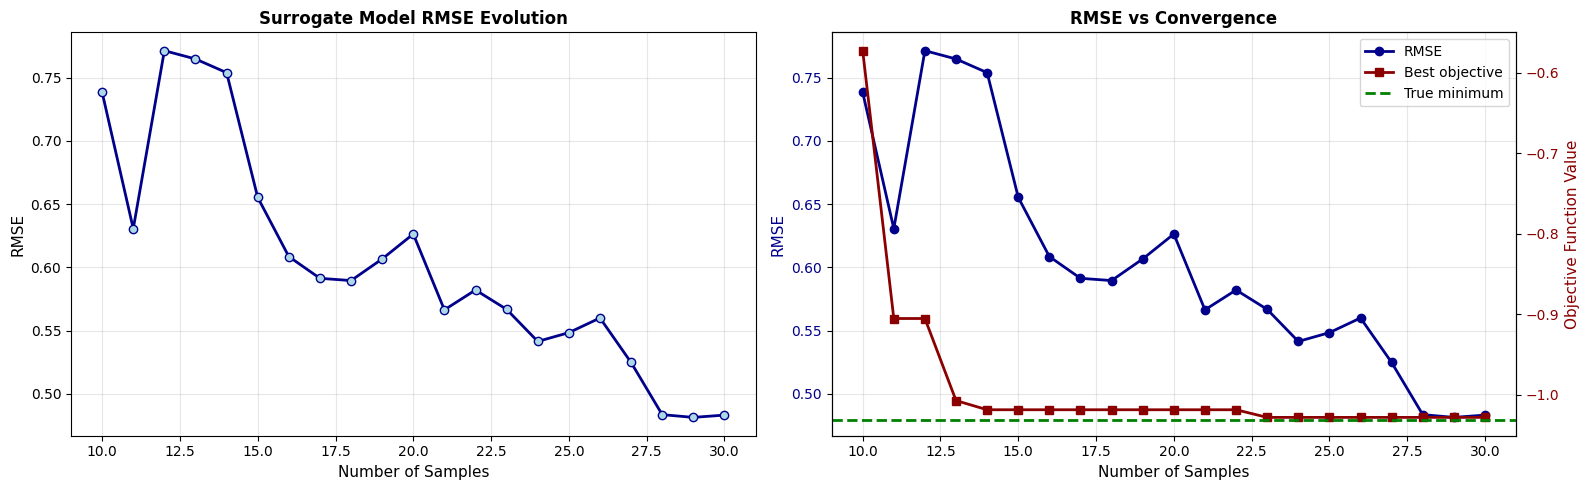


RMSE Analysis:
  Initial RMSE (n=10): 0.7384
  Final RMSE (n=30): 0.4832
  RMSE reduction: 34.56%


In [32]:
# Cell 8: RMSE evolution analysis
# Create validation grid
n_valid = 2000
np.random.seed(42)
X_valid = np.random.uniform(
    low=xlimits[:, 0],
    high=xlimits[:, 1],
    size=(n_valid, 2)
)
y_valid_true = six_hump_camelback(X_valid)

# Compute RMSE at each iteration
rmse_history = []
for i in range(n_initial_doe, len(x_data) + 1):
    x_data_i = x_data[:i]
    y_data_i = y_data[:i].reshape(-1, 1)
    
    ego.gpr.set_training_values(x_data_i, y_data_i)
    ego.gpr.train()
    
    y_valid_pred = ego.gpr.predict_values(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid_true, y_valid_pred))
    rmse_history.append(rmse)

rmse_history = np.array(rmse_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# RMSE evolution
iterations_rmse = np.arange(n_initial_doe, len(x_data) + 1)
ax1.plot(iterations_rmse, rmse_history, 'o-', linewidth=2, color='darkblue',
         markersize=6, markerfacecolor='lightblue', markeredgecolor='darkblue')
ax1.set_xlabel('Number of Samples', fontsize=11)
ax1.set_ylabel('RMSE', fontsize=11)
ax1.set_title('Surrogate Model RMSE Evolution', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# RMSE vs convergence
ax2_twin = ax2.twinx()
ax2.plot(iterations_rmse, rmse_history, 'o-', linewidth=2, color='darkblue',
         label='RMSE', markersize=6)
ax2_twin.plot(iterations_rmse, y_min_history[n_initial_doe-1:], 's-', linewidth=2,
              color='darkred', label='Best objective', markersize=6)
ax2_twin.axhline(y=y_global, color='green', linestyle='--', linewidth=2,
                 label='True minimum')

ax2.set_xlabel('Number of Samples', fontsize=11)
ax2.set_ylabel('RMSE', fontsize=11, color='darkblue')
ax2_twin.set_ylabel('Objective Function Value', fontsize=11, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkblue')
ax2_twin.tick_params(axis='y', labelcolor='darkred')
ax2.set_title('RMSE vs Convergence', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2_twin.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nRMSE Analysis:")
print(f"  Initial RMSE (n={n_initial_doe}): {rmse_history[0]:.4f}")
print(f"  Final RMSE (n={len(x_data)}): {rmse_history[-1]:.4f}")
print(f"  RMSE reduction: {(1 - rmse_history[-1]/rmse_history[0])*100:.2f}%")

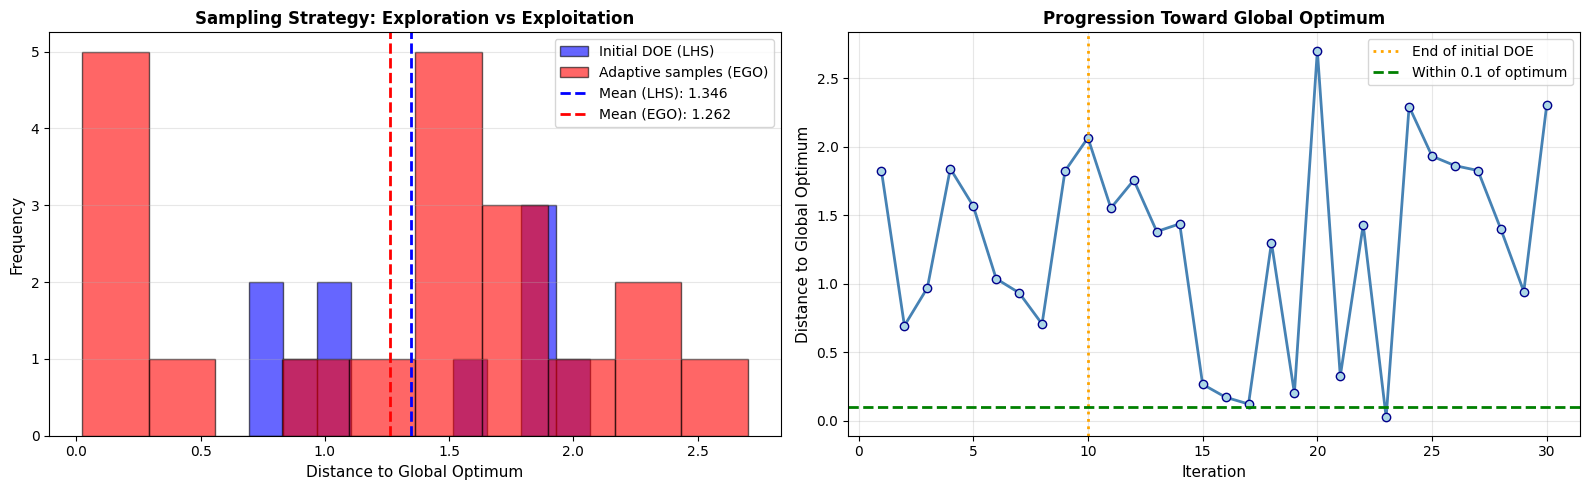


Sampling strategy analysis:
  Initial DOE mean distance to optimum: 1.3459
  Adaptive samples mean distance: 1.2616
  Reduction: 6.27%

  Interpretation: EGO progressively exploits promising regions


In [33]:
# Cell 9: Compare EGO exploitation vs exploration
# Analyze where EGO samples are placed
initial_samples = x_data[:n_initial_doe]
adaptive_samples = x_data[n_initial_doe:]

# Compute distances to global optimum
dist_initial = np.linalg.norm(initial_samples - x_global, axis=1)
dist_adaptive = np.linalg.norm(adaptive_samples - x_global, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Distance distribution
ax1.hist(dist_initial, bins=10, alpha=0.6, label='Initial DOE (LHS)', 
         color='blue', edgecolor='black')
ax1.hist(dist_adaptive, bins=10, alpha=0.6, label='Adaptive samples (EGO)',
         color='red', edgecolor='black')
ax1.axvline(x=dist_initial.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean (LHS): {dist_initial.mean():.3f}')
ax1.axvline(x=dist_adaptive.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean (EGO): {dist_adaptive.mean():.3f}')
ax1.set_xlabel('Distance to Global Optimum', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Sampling Strategy: Exploration vs Exploitation', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Cumulative distance
iterations_all = np.arange(1, len(x_data) + 1)
dist_all = np.linalg.norm(x_data - x_global, axis=1)

ax2.plot(iterations_all, dist_all, 'o-', linewidth=2, markersize=6,
         color='steelblue', markerfacecolor='lightblue', markeredgecolor='darkblue')
ax2.axvline(x=n_initial_doe, color='orange', linestyle=':', linewidth=2,
            label='End of initial DOE')
ax2.axhline(y=0.1, color='green', linestyle='--', linewidth=2,
            label='Within 0.1 of optimum')
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Distance to Global Optimum', fontsize=11)
ax2.set_title('Progression Toward Global Optimum', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSampling strategy analysis:")
print(f"  Initial DOE mean distance to optimum: {dist_initial.mean():.4f}")
print(f"  Adaptive samples mean distance: {dist_adaptive.mean():.4f}")
print(f"  Reduction: {(1 - dist_adaptive.mean()/dist_initial.mean())*100:.2f}%")
print(f"\n  Interpretation: EGO progressively exploits promising regions")


COMPARISON: EGO vs STATIC SAMPLING

Budget: 30 function evaluations

EGO (Adaptive Sampling):
  Best found: f = -1.027880
  Error: 0.003720
  Distance to optimum: 0.0242

Static LHS (5 trials):
  Best found: f = -1.030805
  Worst found: f = -0.668311
  Mean: f = -0.932554
  Std: 0.153273
  Mean error: 0.099046
  Mean distance: 0.6427


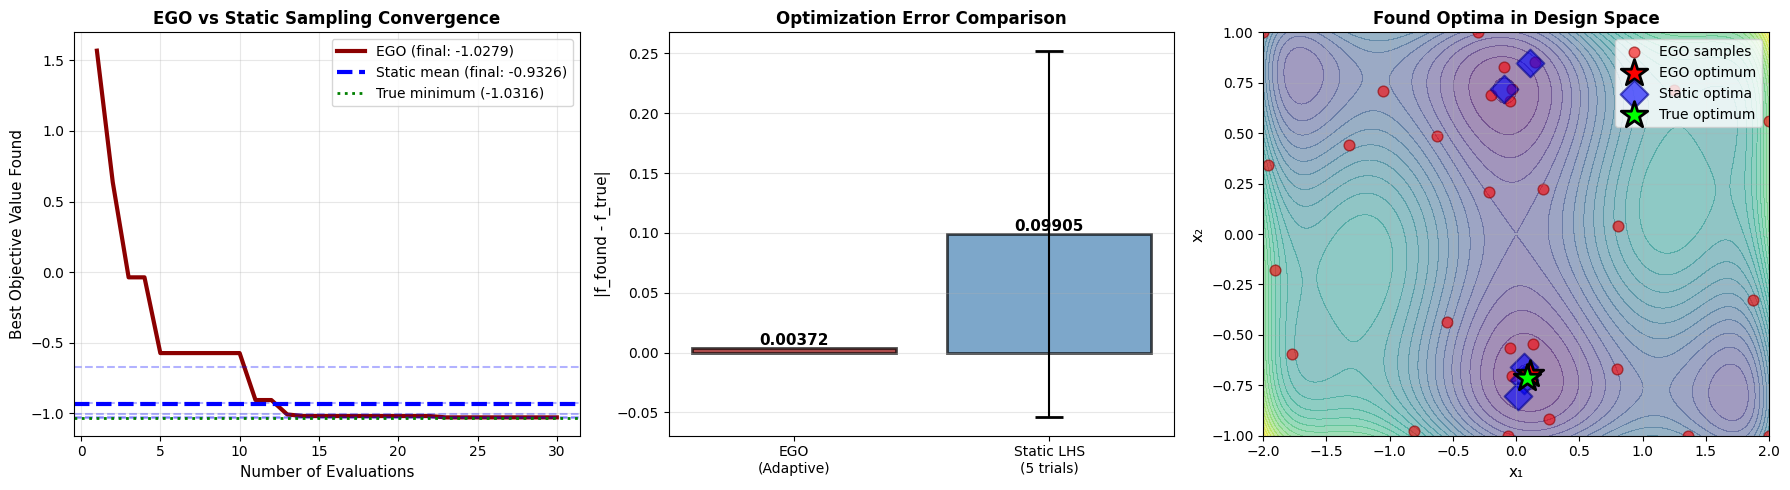

In [34]:
# Cell 10: Compare EGO vs static sampling
# Run static LHS sampling with same budget
total_budget = len(x_data)
n_static_trials = 5

static_results = []
for trial in range(n_static_trials):
    X_static = create_lhs_sample(total_budget, xlimits, seed=42+trial)
    y_static = six_hump_camelback(X_static).flatten()
    
    y_min_static = y_static.min()
    idx_min = np.argmin(y_static)
    x_min_static = X_static[idx_min]
    
    static_results.append({
        'trial': trial + 1,
        'x_opt': x_min_static,
        'y_opt': y_min_static,
        'error': abs(y_min_static - y_global),
        'distance': np.linalg.norm(x_min_static - x_global)
    })

static_df = pd.DataFrame(static_results)

print(f"\n{'='*80}")
print("COMPARISON: EGO vs STATIC SAMPLING")
print(f"{'='*80}")
print(f"\nBudget: {total_budget} function evaluations\n")

print(f"EGO (Adaptive Sampling):")
print(f"  Best found: f = {y_opt[0]:.6f}")
print(f"  Error: {error_final:.6f}")
print(f"  Distance to optimum: {distance_to_global:.4f}\n")

print(f"Static LHS ({n_static_trials} trials):")
print(f"  Best found: f = {static_df['y_opt'].min():.6f}")
print(f"  Worst found: f = {static_df['y_opt'].max():.6f}")
print(f"  Mean: f = {static_df['y_opt'].mean():.6f}")
print(f"  Std: {static_df['y_opt'].std():.6f}")
print(f"  Mean error: {static_df['error'].mean():.6f}")
print(f"  Mean distance: {static_df['distance'].mean():.4f}")
print(f"{'='*80}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convergence comparison
ax = axes[0]
ax.plot(iterations, y_min_history, linewidth=3, color='darkred',
        label=f'EGO (final: {y_opt[0]:.4f})')
for i, row in static_df.iterrows():
    ax.axhline(y=row['y_opt'], color='blue', alpha=0.3, linestyle='--',
               linewidth=1.5)
ax.axhline(y=static_df['y_opt'].mean(), color='blue', linewidth=3,
           linestyle='--', label=f'Static mean (final: {static_df["y_opt"].mean():.4f})')
ax.axhline(y=y_global, color='green', linewidth=2, linestyle=':',
           label=f'True minimum ({y_global:.4f})')
ax.set_xlabel('Number of Evaluations', fontsize=11)
ax.set_ylabel('Best Objective Value Found', fontsize=11)
ax.set_title('EGO vs Static Sampling Convergence', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Error comparison
ax = axes[1]
x_pos = [1, 2]
errors = [error_final, static_df['error'].mean()]
colors = ['darkred', 'steelblue']
bars = ax.bar(x_pos, errors, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.errorbar([2], [static_df['error'].mean()], yerr=[static_df['error'].std()],
            fmt='none', ecolor='black', capsize=10, capthick=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(['EGO\n(Adaptive)', f'Static LHS\n({n_static_trials} trials)'])
ax.set_ylabel('|f_found - f_true|', fontsize=11)
ax.set_title('Optimization Error Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Best solutions in design space
ax = axes[2]
contour = ax.contourf(X1_grid, X2_grid, Y_grid, levels=30, cmap='viridis', alpha=0.5)

# EGO trajectory
ax.scatter(x_data[:, 0], x_data[:, 1], c='red', s=60, alpha=0.6,
           edgecolors='darkred', linewidths=1, label='EGO samples')
ax.scatter(x_opt[0], x_opt[1], c='red', s=400, marker='*',
           edgecolors='black', linewidths=2, label='EGO optimum', zorder=10)

# Static best solutions
for i, row in static_df.iterrows():
    ax.scatter(row['x_opt'][0], row['x_opt'][1], c='blue', s=200, marker='D',
               alpha=0.6, edgecolors='darkblue', linewidths=1.5)

ax.scatter([], [], c='blue', s=200, marker='D', alpha=0.6,
           edgecolors='darkblue', linewidths=1.5, label='Static optima')

# True optimum
ax.scatter(x_global[0], x_global[1], c='lime', s=400, marker='*',
           edgecolors='black', linewidths=2, label='True optimum', zorder=11)

ax.set_xlabel('x₁', fontsize=11)
ax.set_ylabel('x₂', fontsize=11)
ax.set_title('Found Optima in Design Space', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Cell 11: Summary table
summary_data = {
    'Method': ['EGO (Adaptive)', 'Static LHS (Mean)', 'Static LHS (Best)'],
    'f_opt': [y_opt[0], static_df['y_opt'].mean(), static_df['y_opt'].min()],
    'Error': [error_final, static_df['error'].mean(), static_df['error'].min()],
    'Distance_to_optimum': [distance_to_global, static_df['distance'].mean(), static_df['distance'].min()],
    'Total_evaluations': [total_budget, total_budget, total_budget]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*90)
print("CHAPTER 4 SUMMARY: ADAPTIVE vs NON-ADAPTIVE SAMPLING PERFORMANCE")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)
print("\nKey findings:")
print("  1. EGO converges to global optimum with higher reliability")
print("  2. Adaptive sampling is more efficient than static space-filling")
print("  3. Expected Improvement balances exploration and exploitation")
print("  4. Surrogate accuracy (RMSE) improves with adaptive sampling")
print("="*90)


CHAPTER 4 SUMMARY: ADAPTIVE vs NON-ADAPTIVE SAMPLING PERFORMANCE
           Method     f_opt    Error  Distance_to_optimum  Total_evaluations
   EGO (Adaptive) -1.027880 0.003720             0.024154                 30
Static LHS (Mean) -0.932554 0.099046             0.642707                 30
Static LHS (Best) -1.030805 0.000795             0.030241                 30

Key findings:
  1. EGO converges to global optimum with higher reliability
  2. Adaptive sampling is more efficient than static space-filling
  3. Expected Improvement balances exploration and exploitation
  4. Surrogate accuracy (RMSE) improves with adaptive sampling
